In [1]:
import torch
from src.metarcwa import Model, Lattice, Layer, PlaneWave, IsotropicMedium, Stack
from src.metarcwa.model.utils import from_metashapes, from_dispertorch, CallableModule
import matplotlib.pyplot as plt

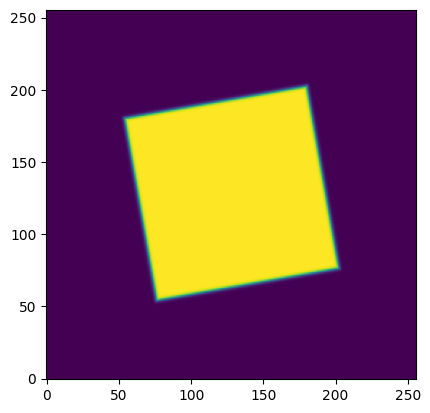

In [2]:
from metashapes.shape import Rectangle

# Lattice
Lx = 400
Ly = 400
lattice = Lattice.rectangular(Lx,Ly)

centre = torch.nn.Parameter(torch.tensor([200.0, 200.0]), requires_grad=True)
size = torch.nn.Parameter(torch.tensor([200.0, 200.0]), requires_grad=True)
angle = torch.nn.Parameter(torch.tensor([10.0]), requires_grad=True)

rect = Rectangle(center=centre, size = size, angle=angle)

shape_fn_0 = from_metashapes(rect, soft = True, softness = 1.0)

mask_0 = shape_fn_0(lattice, 256, 256)

plt.imshow(mask_0.detach(), origin='lower')

{'Au': ['rakic-ld'], 'Ag': ['rakic-ld'], 'Cu': ['rakic-ld'], 'Al': ['rakic-ld'], 'SiO2': ['malitson'], 'Si3N4': ['luke'], 'cSi': ['salzberg'], 'TiO2': ['devore-o'], 'aSi': ['jellison-modine']}
None
torch.Size([50])
torch.complex64


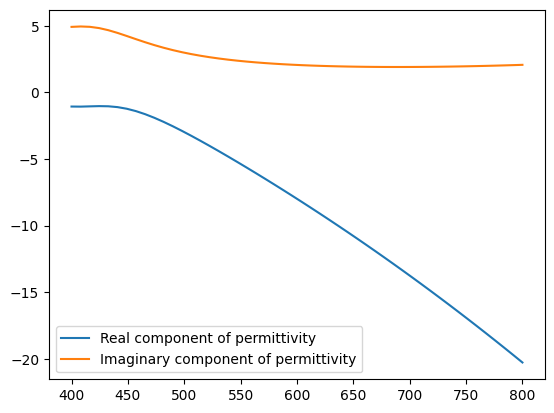

In [3]:
from dispertorch import material, list_materials

print(list_materials())


au = material("Au")
wl = torch.linspace(400,800,50)

au.terms[0].eps_re = torch.nn.Parameter(torch.tensor([1.0]), requires_grad=True)

eps_fn_0 = from_dispertorch(au)
eps_0 = eps_fn_0(wl)
# sum = eps_0.abs().sum()
# sum.backward()

print(au.terms[0].eps_re.grad)

print(eps_0.shape)
print(eps_0.dtype)

plt.plot(wl, eps_0.detach().real, label = "Real component of permittivity")
plt.plot(wl, eps_0.detach().imag, label = "Imaginary component of permittivity")
plt.legend()
plt.show()

In [4]:
# Create a layer
def air_fn(wl):
    return (1 + 0j)*torch.ones_like(wl)

au_medium = IsotropicMedium(eps_fn_0)
sio2_medium = IsotropicMedium(from_dispertorch(material('SiO2')))
air_medium = IsotropicMedium(CallableModule(air_fn))

layer_0 = Layer(
    medium_solid=au_medium,
    thickness = torch.tensor(100.0),
    medium_void=air_medium,
    shape_fn = shape_fn_0
)
layer_1 = Layer(
    medium_solid=sio2_medium,
    thickness = torch.tensor(200.0),
)


In [5]:
# Create Stack
stack = Stack(air_medium, layers=[layer_0, layer_1], transmission=air_medium, lattice=lattice)

# Create Source
theta = torch.linspace(0, 45, 46)
phi = torch.linspace(0, 10, 11)
s_amp = 1.0
p_amp = 0.0
source = PlaneWave(wl, s_amp, p_amp, theta, phi)

In [6]:
# Create model
model = Model(stack, source)
model = model.to(dtype = torch.float32, device='cuda:0')
for name, param in model.named_parameters():
    print(name, param)

model_spec = model.spec(nx=128, ny=128)

stack.layers.0.medium_solid.eps_fn._deps.0.terms.0.eps_re Parameter containing:
tensor([1.], device='cuda:0', requires_grad=True)
stack.layers.0.shape_fn._deps.0.center Parameter containing:
tensor([200., 200.], device='cuda:0', requires_grad=True)
stack.layers.0.shape_fn._deps.0.size Parameter containing:
tensor([200., 200.], device='cuda:0', requires_grad=True)
stack.layers.0.shape_fn._deps.0.angle Parameter containing:
tensor([10.], device='cuda:0', requires_grad=True)


In [7]:
from tests.model.utils import iter_tensors, describe_tensors

describe_tensors(model_spec)

layers.0.thickness             shape=torch.Size([]) device=cuda:0  dtype=torch.float32  requires_grad=False  grad_fn=None
layers.0.medium_solid.eps      shape=torch.Size([50]) device=cuda:0  dtype=torch.complex64  requires_grad=True  grad_fn=<AddBackward0 object at 0x7dca71df8370>
layers.0.medium_void.eps       shape=torch.Size([50]) device=cuda:0  dtype=torch.complex64  requires_grad=False  grad_fn=None
layers.0.pattern               shape=torch.Size([128, 128]) device=cuda:0  dtype=torch.float32  requires_grad=True  grad_fn=<SigmoidBackward0 object at 0x7dca71df8370>
layers.1.thickness             shape=torch.Size([]) device=cuda:0  dtype=torch.float32  requires_grad=False  grad_fn=None
layers.1.medium.eps            shape=torch.Size([50]) device=cuda:0  dtype=torch.complex64  requires_grad=False  grad_fn=None
incidence.eps                  shape=torch.Size([50]) device=cuda:0  dtype=torch.complex64  requires_grad=False  grad_fn=None
transmission.eps               shape=torch.Size([5